In [22]:
import BioSimSpace as bss
from pathlib import Path
import glob
import os
import pandas as pd

# Set the repo path


This is only relevant for this example, in your case you will setup the path to your inputs. 

In [5]:
REPO_ROOT = Path().resolve()
DATA_DIR = REPO_ROOT / "data"

In [7]:
ligand_inputs = os.path.join(
    DATA_DIR, "inputs", "ligands"
)

# 1. Load ligand files into BioSimSpace

In [8]:
ligand_files = sorted(glob.glob(
    f"{ligand_inputs}/*.sdf"
))

print(f"Found {len(ligand_files)} ligand files in path:\n{ligand_inputs}")

Found 2 ligand files in path:
/Users/af25016/projects/ligand_rbfe/data/inputs/ligands


In [13]:
ligand_molecules = [bss.IO.readMolecules(ligand_file)[0] for ligand_file in ligand_files]
ligand_names = [os.path.basename(ligand_file).split(".")[0] for ligand_file in ligand_files]

ligand_molecules, ligand_names

([<BioSimSpace.Molecule: number=4, nAtoms=30, nResidues=1>,
  <BioSimSpace.Molecule: number=5, nAtoms=28, nResidues=1>],
 ['ligand_1', 'ligand_2'])

# 2. Create network

INFO:root:------------------------------
INFO:root:ID 0	000_ligand_1.sdf
INFO:root:ID 1	001_ligand_2.sdf
INFO:root:------------------------------
INFO:root:Finish reading input files. 2 structures in total....skipped 0

INFO:root:
Matrix scoring in progress....

INFO:root:Parallel mode is on
INFO:root:
Generating graph in progress....
INFO:root:------------------------------
INFO:root:The following files have been generated:
/Users/af25016/projects/ligand_rbfe/data/inputs/ligands/outputs/lomap.txt	Mapping Text file
INFO:root:------------------------------


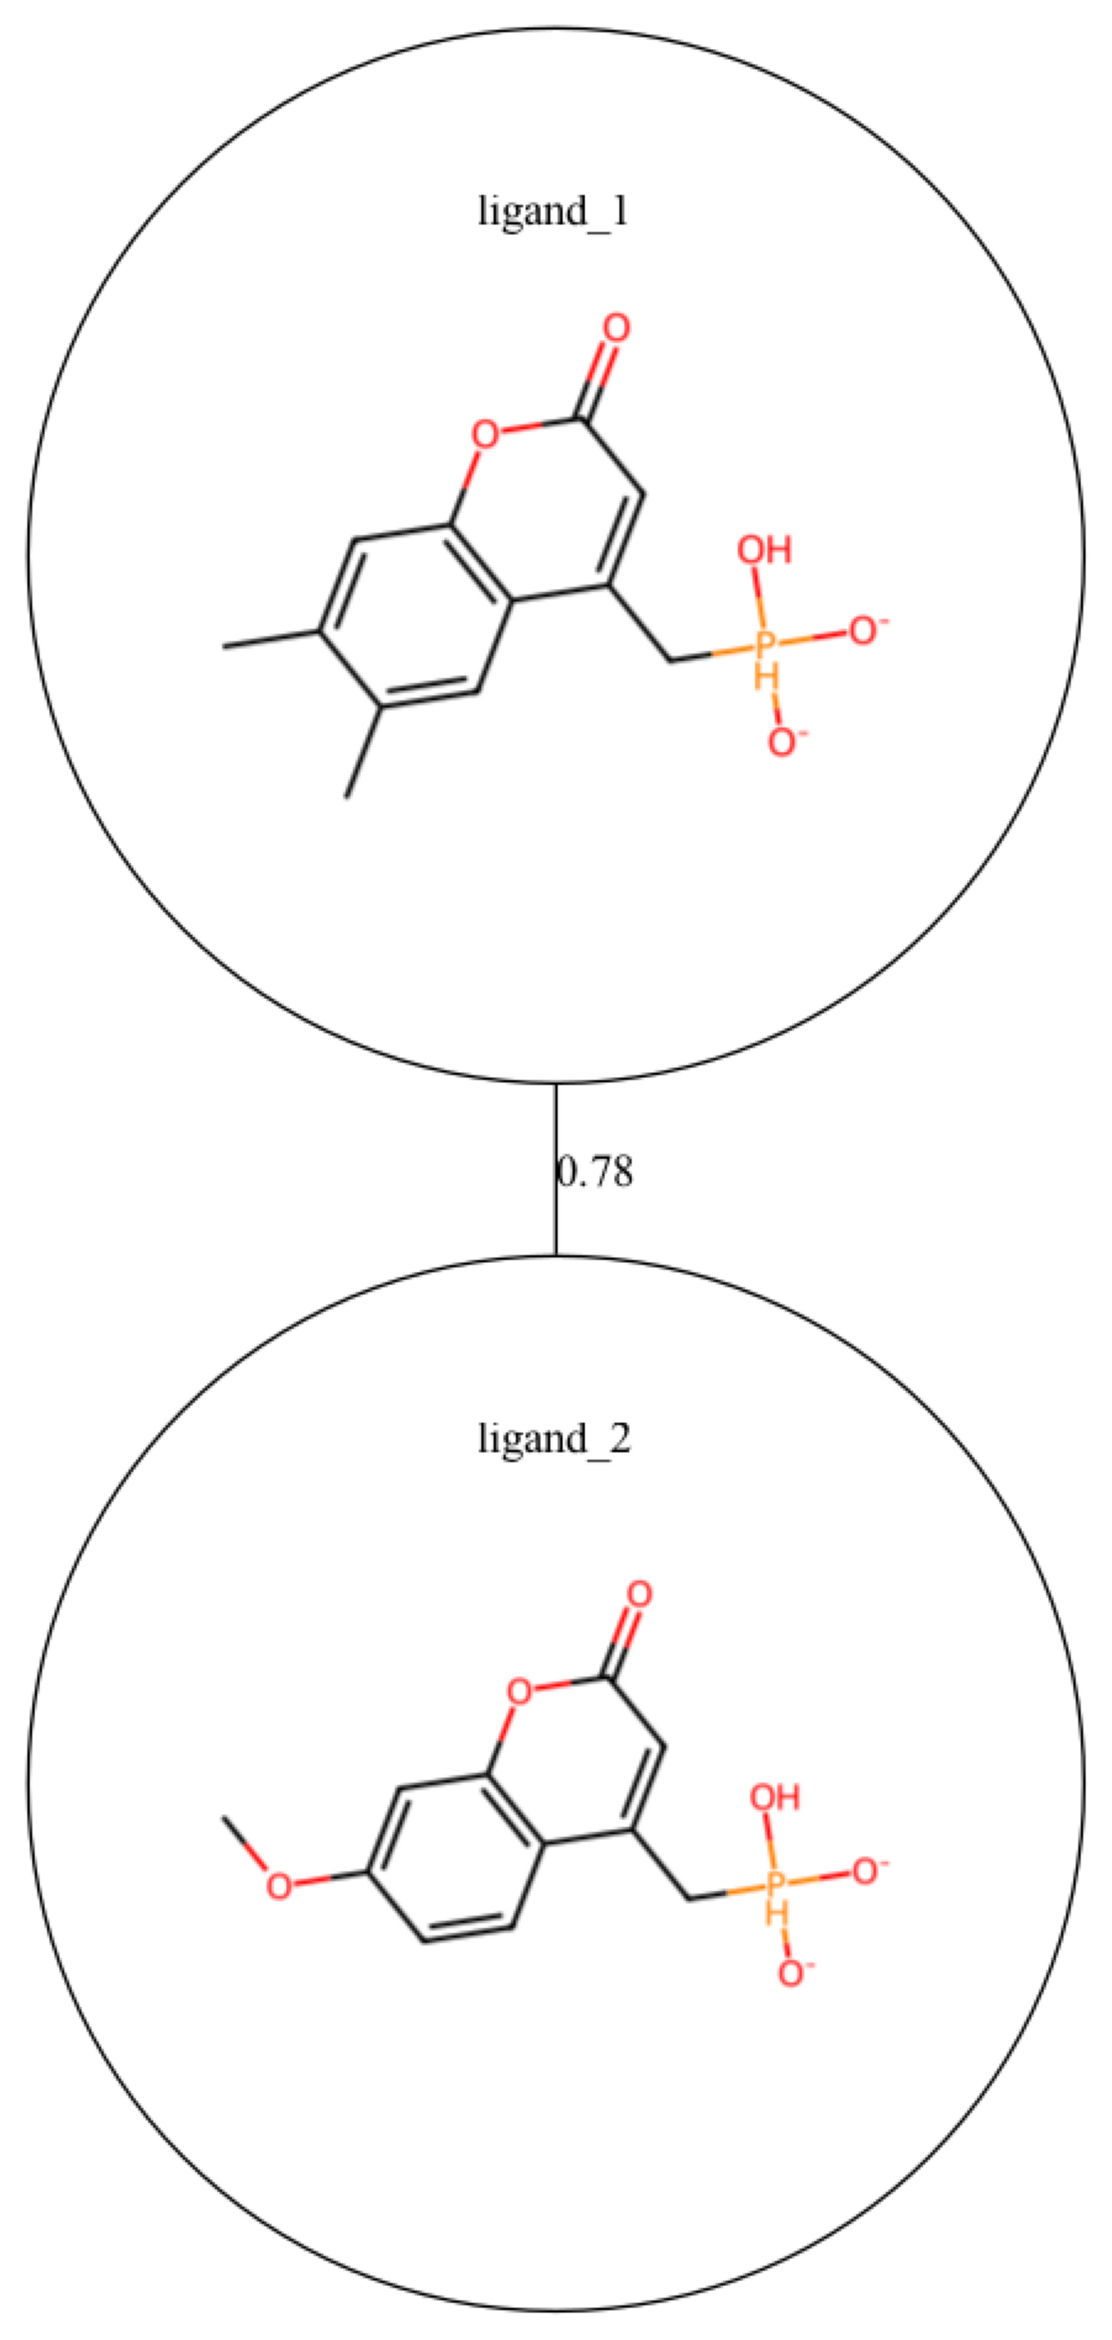

In [14]:
transformations, scores = bss.Align.generateNetwork(
    molecules=ligand_molecules,
    names=ligand_names,
    work_dir=ligand_inputs,
    plot_network=True
)

This will create three new directories in the given directory. The above image is automatically saved to `images/network.png`. 

The transformations themselves are not saved in a very human-readable file, so we will do that in the next step.

# 3. Write transformations to a file

First, create a dictionary of the transformations:

In [19]:
network_dictionary = {}

named_transformations = [
    f"{ligand_names[transformation[0]]}~{ligand_names[transformation[1]]}" for transformation in transformations
]

for score, transformation in sorted(zip(scores, named_transformations)):
    network_dictionary[transformation] = score
    print(transformation, score)

network_dictionary

ligand_1~ligand_2 0.7788


{'ligand_1~ligand_2': 0.7788}

I like to convert it to a Pandas dataframe to make it easier to save:

In [25]:
network_dataframe = pd.DataFrame(
    [(key, value) for key, value in network_dictionary.items()], columns=["transformations", "score"]
)
network_dataframe

,transformations,score
0,ligand_1~ligand_2,0.7788


Then we can write the dataframe to a csv file:

In [26]:
network_file = os.path.join(
    ligand_inputs, "outputs", "network.csv"
)

network_dataframe.to_csv(network_file)
